In [84]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lakshmi25npathi_imdb_dataset_of_50k_movie_reviews_path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

print('Data source import complete.')


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Data source import complete.


In [85]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [86]:
!pip install tensorflow

**Import Library Dependencies**

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Embedding, LSTM,GRU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

**Exploratory Data analysis**.

In [88]:
df=pd.read_csv("/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [89]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [90]:
df.tail()

,review,sentiment
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative
49999,No one expects the Star Trek movies to be high...,negative


In [91]:
df.shape

(50000, 2)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [93]:
df.size

100000

In [94]:
df.isnull().sum()

,0
review,0
sentiment,0


In [95]:
df.replace({"sentiment":{"positive":1, "negative":0}}, inplace=True)

/tmp/ipykernel_859/1008295852.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"sentiment":{"positive":1, "negative":0}}, inplace=True)


In [96]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [97]:
df["sentiment"].value_counts()

,count
sentiment,
1,25000
0,25000


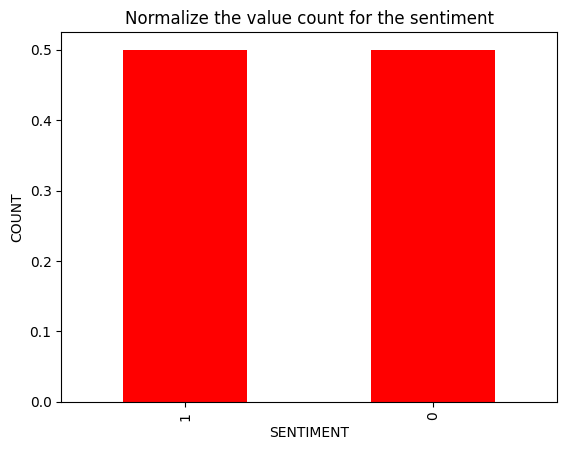

In [98]:
df["sentiment"].value_counts(normalize=True).plot(kind="bar", color="red",
                                    xlabel="SENTIMENT",
                                    ylabel="COUNT",
                                    title="Normalize the value count for the sentiment"
                                   );

In [99]:
#split data into training data and test data
train_df, test_df=train_test_split(df, test_size=0.2, random_state=42)

In [100]:
print(train_df.shape)

(40000, 2)


In [101]:
print(test_df.shape)

(10000, 2)


In [102]:
train_df.head()

,review,sentiment
39087,That's what I kept asking myself during the ma...,0
30893,I did not watch the entire movie. I could not ...,0
45278,A touching love story reminiscent of In the M...,1
16398,This latter-day Fulci schlocker is a totally a...,0
13653,"First of all, I firmly believe that Norwegian ...",0


sentiment
0    20039
1    19961
Name: count, dtype: int64


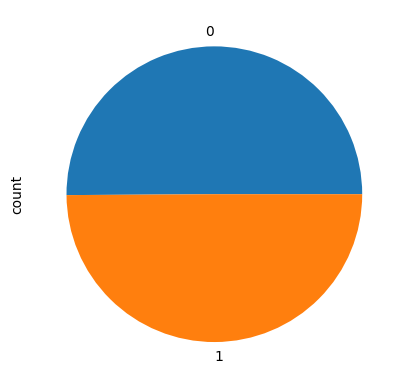

In [103]:
print(train_df["sentiment"].value_counts())
train_df["sentiment"].value_counts().plot(kind="pie");


In [104]:
test_df.head()

,review,sentiment
33553,I really liked this Summerslam due to the look...,1
9427,Not many television shows appeal to quite as m...,1
199,The film quickly gets to a major chase scene w...,0
12447,Jane Austen would definitely approve of this o...,1
39489,Expectations were somewhat high for me when I ...,0


Value Count for  the test sentiment Analysis: sentiment
1    5039
0    4961
Name: count, dtype: int64


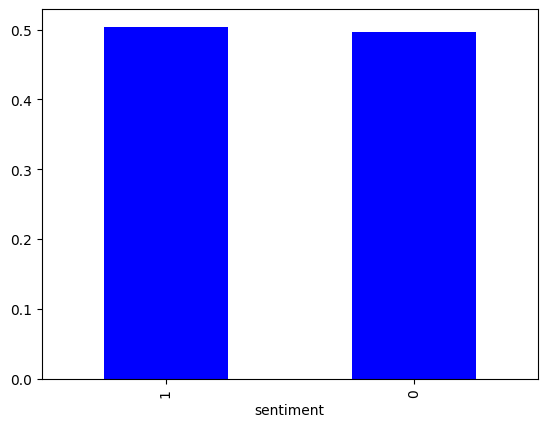

In [105]:
print("Value Count for  the test sentiment Analysis:", test_df["sentiment"].value_counts())
test_df["sentiment"].value_counts(normalize=True).plot(kind="bar", color="b");

**Data Preprocessing**

In [106]:
tokenizer=Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_df["review"])
X_train = pad_sequences(tokenizer.texts_to_sequences(train_df["review"]), maxlen=200)
X_test=pad_sequences(tokenizer.texts_to_sequences(test_df["review"]), maxlen=200)

In [107]:
print(X_train)

[[1935    1 1200 ...  205  351 3856]
 [   3 1651  595 ...   89  103    9]
 [   0    0    0 ...    2  710   62]
 ...
 [   0    0    0 ... 1641    2  603]
 [   0    0    0 ...  245  103  125]
 [   0    0    0 ...   70   73 2062]]


In [108]:
print(X_test)

[[   0    0    0 ...  995  719  155]
 [  12  162   59 ...  380    7    7]
 [   0    0    0 ...   50 1088   96]
 ...
 [   0    0    0 ...  125  200 3241]
 [   0    0    0 ... 1066    1 2305]
 [   0    0    0 ...    1  332   27]]


In [109]:
y_train = train_df["sentiment"]
y_test =test_df["sentiment"]

In [110]:
print(y_train)

39087    0
30893    0
45278    1
16398    0
13653    0
        ..
11284    1
44732    1
38158    0
860      1
15795    1
Name: sentiment, Length: 40000, dtype: int64


In [111]:
print(y_test)

33553    1
9427     1
199      0
12447    1
39489    0
        ..
28567    0
25079    1
18707    1
15200    0
5857     1
Name: sentiment, Length: 10000, dtype: int64


**LONG-SHORT TERM MEMORY-LSTM**

In [112]:
## Build the model
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128, input_length=200))
model.add(GRU(128, activation='tanh'))



model.add(Dense(1, activation="sigmoid"))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [113]:
#compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

**Training the Model**

In [114]:
model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7899 - loss: 0.4350 - val_accuracy: 0.8636 - val_loss: 0.3224
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8882 - loss: 0.2734 - val_accuracy: 0.8888 - val_loss: 0.2780
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9219 - loss: 0.2059 - val_accuracy: 0.8930 - val_loss: 0.2734
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9428 - loss: 0.1552 - val_accuracy: 0.8850 - val_loss: 0.2941
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9591 - loss: 0.1151 - val_accuracy: 0.8861 - val_loss: 0.3800


**Model Evaluation**

In [115]:
loss,accuracy = model.evaluate(X_test,y_test)
print(f"Test Loss:{loss}")
print(f"Test Accuracy:{accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8864 - loss: 0.3534
Test Loss:0.3533766567707062
Test Accuracy:0.8863999843597412


In [116]:
# Predict and evaluate using confusion matrix
Y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, Y_pred)
print("Confusion Matrix:\n", cm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Confusion Matrix:
 [[4282  679]
 [ 457 4582]]


In [117]:
# Performance metrics
report = classification_report(y_test, Y_pred, target_names=['Negative', 'Positive'])
print("Classification Report:\n", report)

Classification Report:
               precision    recall  f1-score   support

    Negative       0.90      0.86      0.88      4961
    Positive       0.87      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



**Building a Predictive System**

In [118]:
def predict_sentiment(review):
  # tokenize and pad the review
  sequence = tokenizer.texts_to_sequences([review])
  padded_sequence = pad_sequences(sequence, maxlen=200)
  prediction = model.predict(padded_sequence)
  sentiment = 'positive' if prediction[0][0] > 0.5 else 'negative'
  return sentiment

In [119]:
# example usage
new_review = 'i like this movie'
sentiment = predict_sentiment(new_review)
print(f'The sentiment of the review is: {sentiment}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
The sentiment of the review is: positive


In [120]:
new_review = 'This Movie was not that good'
sentiment = predict_sentiment(new_review)
print(f'The sentiment of the review is: {sentiment}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
The sentiment of the review is: negative


In [124]:
new_review = ' it NOT GOOD'
sentiment = predict_sentiment(new_review)
print(f'The sentiment of the review is: {sentiment}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
The sentiment of the review is: positive
